# 0. Imports

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import datetime
import inflection
import math

from IPython.display import Image

ModuleNotFoundError: No module named 'pandas'

## 0.1. Helper Functions and Variables

In [2]:
columns = lambda x: inflection.underscore(x)

## 0.2. Loading Data

In [3]:
df_sales_raw = pd.read_csv('data/train.csv', low_memory=False)
df_store_raw = pd.read_csv('data/store.csv', low_memory=False)

df = df_sales_raw.merge(df_store_raw, on="Store")
EPS = 1e-6

In [4]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,4,2015-07-30,5020,546,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,3,2015-07-29,4782,523,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,1,2,2015-07-28,5011,560,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
4,1,1,2015-07-27,6102,612,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


# 1.0. Data Description

## 1.1. Rename Columns

In [5]:
new_cols = [columns(col) for col in df.columns]
df.columns = new_cols

In [6]:
df.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval'],
      dtype='object')

## 1.2. Data Dimensions

In [7]:
df.shape

(1017209, 18)

## 1.3. Data Types

In [8]:
df.dtypes

store                             int64
day_of_week                       int64
date                             object
sales                             int64
customers                         int64
open                              int64
promo                             int64
state_holiday                    object
school_holiday                    int64
store_type                       object
assortment                       object
competition_distance            float64
competition_open_since_month    float64
competition_open_since_year     float64
promo2                            int64
promo2_since_week               float64
promo2_since_year               float64
promo_interval                   object
dtype: object

In [9]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

## 1.4. Check NA

In [10]:
df.isnull().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## 1.5. Fillout NA

In [11]:
# competition_distance
INF_COMP_DISTANCE = max(df['competition_distance']) / EPS
df.loc[df['competition_distance'].isnull(), 'competition_distance'] = INF_COMP_DISTANCE

# competition_open_since_month
df['competition_open_since_month'] = df.apply(lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis=1)

# competition_open_since_year
df['competition_open_since_year'] = df.apply(lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis=1)

# promo2_since_week
df['promo2_since_week'] = df.apply(lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis=1)

# promo2_since_year
df['promo2_since_year'] = df.apply(lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis=1)

# promo_interval
df['promo_interval'].fillna(0, inplace=True)

month_map = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

df['month_map'] = df['date'].dt.month.map(month_map)

df['is_promo'] = df.apply(lambda x: 1 if (x['promo_interval'] != 0) and (x['month_map'] in x['promo_interval']) else 0, axis=1)

In [12]:
df.sample(5).T

,661487,627481,40912,695094,422503
store,727,689,45,763,463
day_of_week,7,6,4,3,2
date,2014-06-15 00:00:00,2014-02-01 00:00:00,2014-01-09 00:00:00,2013-04-10 00:00:00,2013-07-30 00:00:00
sales,0,5654,6162,5134,6924
customers,0,602,465,511,1017
open,0,1,1,1,1
promo,0,0,1,1,1
state_holiday,0,0,0,0,0
school_holiday,0,0,0,0,1
store_type,a,d,d,d,a


## 1.6. Change Data Types

In [13]:
df.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
month_map                               object
is_promo                                 int64
dtype: object

## 1.7. Descriptive Statistical (negócio e erros)

In [14]:
df['competition_open_since_month'] = df['competition_open_since_month'].astype(int)
df['competition_open_since_year'] = df['competition_open_since_year'].astype(int)

df['promo2_since_week'] = df['promo2_since_week'].astype(int)
df['promo2_since_year'] = df['promo2_since_year'].astype(int)

In [15]:
num_attributes = df.select_dtypes(include=['int64', 'float64'])
cat_attributes = df.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

### 1.7.1. Numeric Attributes

In [16]:
mean = pd.DataFrame(num_attributes.apply(np.mean)).T
median = pd.DataFrame(num_attributes.apply(np.median)).T
std = pd.DataFrame(num_attributes.apply(np.std)).T
min = pd.DataFrame(num_attributes.apply(min)).T
max = pd.DataFrame(num_attributes.apply(max)).T
range = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
skew = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
kurt = pd.DataFrame(num_attributes.apply(lambda x: x.kurt())).T

In [17]:
df_num_metrics = pd.concat([mean, median, std, min, max, range, skew, kurt]).T
columns = ['mean', 'median', 'std', 'min', 'max', 'range', 'skew', 'kurt']
df_num_metrics.columns = columns

In [18]:
df_num_metrics

,mean,median,std,min,max,range,skew,kurt
store,5.584297e+02,558.0,3.219085e+02,1.0,1.115000e+03,1.114000e+03,-0.000955,-1.200524
day_of_week,3.998341e+00,4.0,1.997390e+00,1.0,7.000000e+00,6.000000e+00,0.001593,-1.246873
sales,5.773819e+03,5744.0,3.849924e+03,0.0,4.155100e+04,4.155100e+04,0.641460,1.778375
customers,6.331459e+02,609.0,4.644115e+02,0.0,7.388000e+03,7.388000e+03,1.598650,7.091773
open,8.301067e-01,1.0,3.755390e-01,0.0,1.000000e+00,1.000000e+00,-1.758045,1.090723
promo,3.815145e-01,0.0,4.857584e-01,0.0,1.000000e+00,1.000000e+00,0.487838,-1.762018
school_holiday,1.786467e-01,0.0,3.830562e-01,0.0,1.000000e+00,1.000000e+00,1.677842,0.815154
competition_distance,1.970368e+08,2330.0,3.861085e+09,20.0,7.586000e+10,7.586000e+10,19.545293,380.019239
competition_open_since_month,6.786849e+00,7.0,3.311085e+00,1.0,1.200000e+01,1.100000e+01,-0.042076,-1.232607
competition_open_since_year,2.010325e+03,2012.0,5.515591e+00,1900.0,2.015000e+03,1.150000e+02,-7.235657,124.071304


/home/henrique/.local/share/virtualenvs/ds_prod-wPDoz9Z5/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/henrique/.local/share/virtualenvs/ds_prod-wPDoz9Z5/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


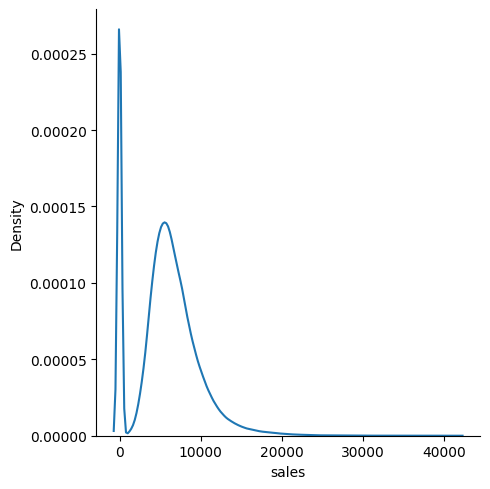

In [19]:
sns.displot(num_attributes['sales'], kind='kde')

### 1.7.2 Categorical Attributes

In [20]:
cat_attributes.apply(lambda x: len(x.unique()))

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

/home/henrique/.local/share/virtualenvs/ds_prod-wPDoz9Z5/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/henrique/.local/share/virtualenvs/ds_prod-wPDoz9Z5/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/henrique/.local/share/virtualenvs/ds_prod-wPDoz9Z5/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/henrique/.local/share/virtualenvs/ds_prod-wPDoz9Z5/lib/python3.10/site-packages/seaborn/_oldcore.

<Axes: xlabel='assortment', ylabel='sales'>

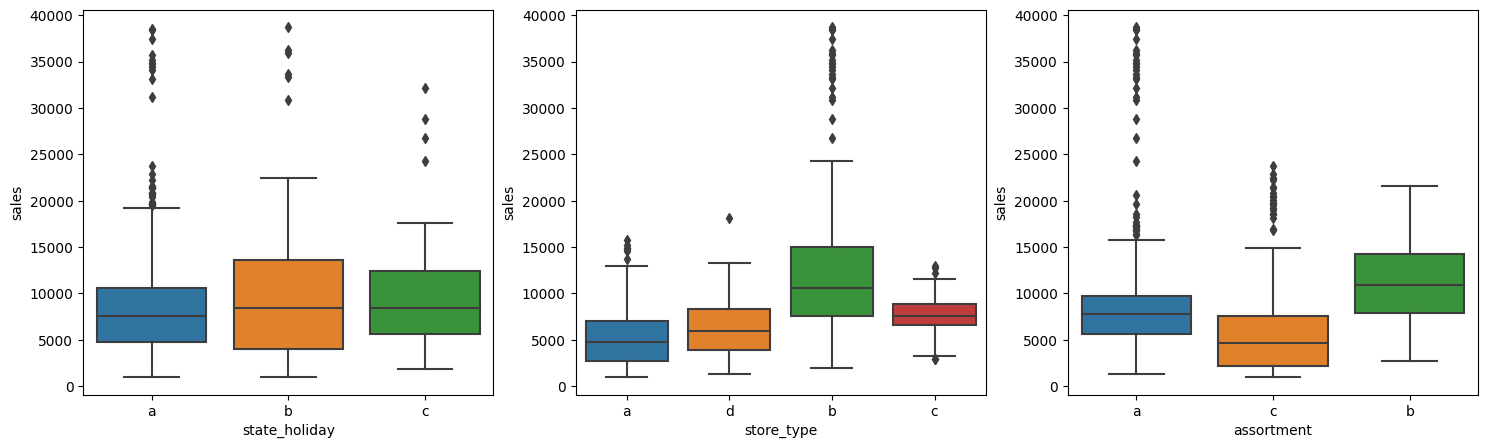

In [21]:
aux = df[(df['state_holiday'] != '0') & (df['sales'] > 0)]

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='state_holiday', y='sales', data=aux)

plt.subplot(1, 3, 2)
sns.boxplot(x='store_type', y='sales', data=aux)

plt.subplot(1, 3, 3)
sns.boxplot(x='assortment', y='sales', data=aux)

# 2. Passo 2 - Feature Engineering

## 2.1. MindMap de Hipóteses

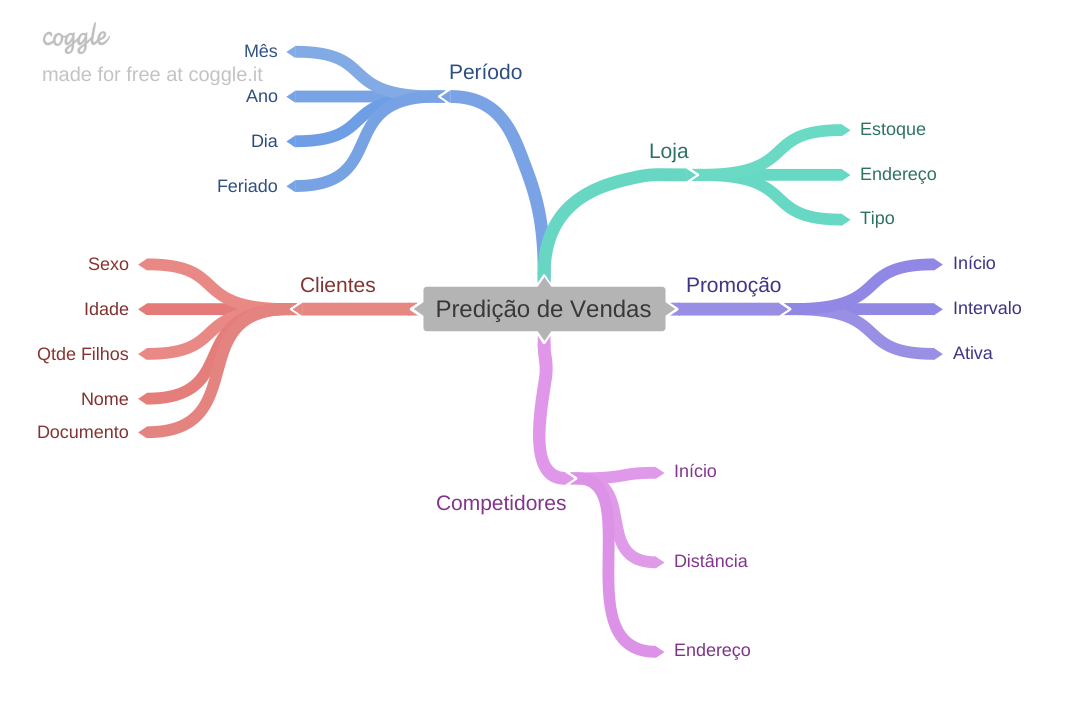

In [23]:
Image('img/hypothesis-mindmap.png')

## 2.2. Hipóteses

### 2.2.1. Loja

**1.** Loja com maior número de funcionários deveria vender menos

**2.** Lojas com maior capacidade de estoque deveriam vender mais

**3.** Lojas com maior porte deveriam vender mais

**4.** Lojas com maior sortimento deveriam vender mais

**5.** Lojas com competidores mais próximos deveriam vender menos

**6.** Lojas com competidores há mais tempo deveriam vender mais

### 2.2.1. Produto

**1.** Lojas que investem mais em Marketing deveriam vender mais

**2.** Lojas com maior exposição de produto deveriam vender mais

**3.** Lojas com produtos com preço menor deveriam vender mais

**4.** Lojas com promoções mais agressivas (preços menores) deveriam vender mais

**5.** Lojas com promoções ativas por mais tempo deveriam vender mais

**6.** Lojas com mais dias de promoção deveriam vender mais

**7.** Lojas com mais promoções consecutivas deveriam vender mais

### 2.2.1. Tempo

**1.** Lojas abertas durante o feriado de Natal deveriam vender mais

**2.** Lojas deveriam vender mais ao longo dos anos

**3.** Lojas deveriam vender mais no segundo semestre do ano

**4.** Lojas deveriam vender mais depois do dia 10 de cada mês

**5.** Lojas deveriam vender menos nos finais de semana

**6.** Lojas deveriam vender menos nos durante feriados escolares

## 2.3. Lista final de hipóteses

**1.** Lojas com maior sortimento deveriam vender mais

**2.** Lojas com competidores mais próximos deveriam vender menos

**3.** Lojas com competidores há mais tempo deveriam vender mais

**4.** Lojas com promoções ativas por mais tempo deveriam vender mais

**5.** Lojas com mais dias de promoção deveriam vender mais

**6.** Lojas com mais promoções consecutivas deveriam vender mais

**7.** Lojas abertas durante o feriado de Natal deveriam vender mais

**8.** Lojas deveriam vender mais ao longo dos anos

**9.** Lojas deveriam vender mais no segundo semestre do ano

**10.** Lojas deveriam vender mais depois do dia 10 de cada mês

**11.** Lojas deveriam vender menos nos finais de semana

**12.** Lojas deveriam vender menos nos durante feriados escolares

In [ ]:
# year
# month
# day
# week_of_year
# year_week

# competition since
# competition time month
# promo since

# assortment
# state holiday